# Cookie Cats 유저 행동 분석 — 최종 인사이트 요약

<>:13: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:13: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\tangb\AppData\Local\Temp\ipykernel_28508\1645861487.py:13: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df = pd.read_csv('..\data\cookie_cats.csv\cookie_cats.csv')


       Cookie Cats 유저 분석 최종 요약

전체 유저 수       : 90,189명
전체 D1 리텐션     : 44.5%
전체 D7 리텐션     : 18.6%

--- Funnel ---
설치 후 1라운드 플레이 : 95.6%
10라운드 이상 플레이   : 62.0%
D1 복귀               : 44.5%
D7 복귀               : 18.6%

--- 핵심 코호트 ---
01_초반(1-5) → D1: 6.8% / D7: 1.3%
02_중초반(6-15) → D1: 26.5% / D7: 3.9%
03_중반(16-30) → D1: 51.9% / D7: 9.9%
04_후반(31-60) → D1: 70.7% / D7: 20.8%
05_헤비(61+) → D1: 86.9% / D7: 59.3%

--- A/B 테스트 ---
gate_30 D7 리텐션 : 19.0%
gate_40 D7 리텐션 : 18.2%
p-value           : 0.0016 → 통계적으로 유의미


C:\Users\tangb\AppData\Local\Temp\ipykernel_28508\1645861487.py:190: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Malgun Gothic.
  plt.savefig('../images/final_dashboard.png', dpi=150, bbox_inches='tight')
c:\DA\cookie-cats-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


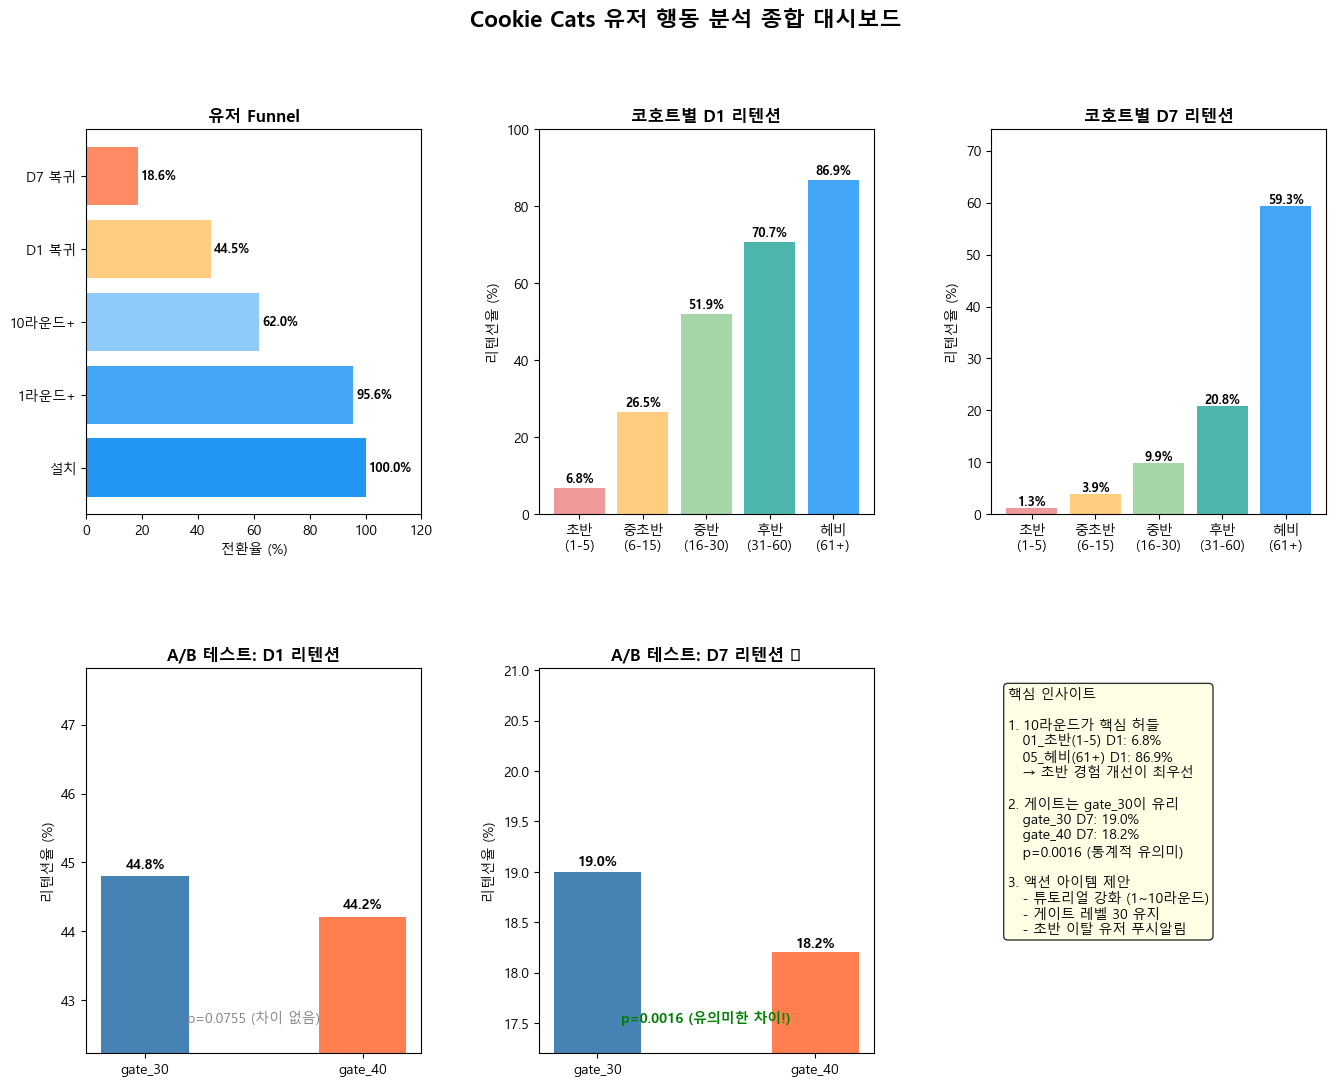


최종 대시보드 저장 완료!


In [1]:
# =====================
# 1. 라이브러리 로드
# =====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('..\data\cookie_cats.csv\cookie_cats.csv')

# =====================
# 2. 전체 분석 결과 한 번에 정리
# =====================
gate_30 = df[df['version'] == 'gate_30']
gate_40 = df[df['version'] == 'gate_40']

total = len(df)
d1 = df['retention_1'].mean()
d7 = df['retention_7'].mean()

play_1plus  = (df['sum_gamerounds'] >= 1).sum() / total * 100
play_10plus = (df['sum_gamerounds'] >= 10).sum() / total * 100

d1_g30 = gate_30['retention_1'].mean() * 100
d1_g40 = gate_40['retention_1'].mean() * 100
d7_g30 = gate_30['retention_7'].mean() * 100
d7_g40 = gate_40['retention_7'].mean() * 100

d1_ct = pd.crosstab(df['version'], df['retention_1'])
d7_ct = pd.crosstab(df['version'], df['retention_7'])
_, p_d1, _, _ = stats.chi2_contingency(d1_ct)
_, p_d7, _, _ = stats.chi2_contingency(d7_ct)

def assign_cohort(rounds):
    if rounds <= 5:
        return '01_초반(1-5)'
    elif rounds <= 15:
        return '02_중초반(6-15)'
    elif rounds <= 30:
        return '03_중반(16-30)'
    elif rounds <= 60:
        return '04_후반(31-60)'
    else:
        return '05_헤비(61+)'

df['cohort'] = df['sum_gamerounds'].apply(assign_cohort)

cohort_ret = df.groupby('cohort').agg(
    D1=('retention_1', 'mean'),
    D7=('retention_7', 'mean'),
).round(4)

print("=" * 50)
print("       Cookie Cats 유저 분석 최종 요약")
print("=" * 50)

print(f"\n전체 유저 수       : {total:,}명")
print(f"전체 D1 리텐션     : {d1:.1%}")
print(f"전체 D7 리텐션     : {d7:.1%}")

print("\n--- Funnel ---")
print(f"설치 후 1라운드 플레이 : {play_1plus:.1f}%")
print(f"10라운드 이상 플레이   : {play_10plus:.1f}%")
print(f"D1 복귀               : {d1:.1%}")
print(f"D7 복귀               : {d7:.1%}")

print("\n--- 핵심 코호트 ---")
for name, row in cohort_ret.iterrows():
    print(f"{name} → D1: {row['D1']:.1%} / D7: {row['D7']:.1%}")

print("\n--- A/B 테스트 ---")
print(f"gate_30 D7 리텐션 : {d7_g30:.1f}%")
print(f"gate_40 D7 리텐션 : {d7_g40:.1f}%")
print(f"p-value           : {p_d7:.4f} → {'통계적으로 유의미' if p_d7 < 0.05 else '유의미하지 않음'}")

# =====================
# 3. 최종 대시보드 시각화
# =====================
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Cookie Cats 유저 행동 분석 종합 대시보드',
             fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# --- 1번: Funnel ---
ax1 = fig.add_subplot(gs[0, 0])
funnel_stages = ['설치', '1라운드+', '10라운드+', 'D1 복귀', 'D7 복귀']
funnel_values = [100.0, round(play_1plus, 1), round(play_10plus, 1),
                 round(d1 * 100, 1), round(d7 * 100, 1)]
colors_funnel = ['#2196F3', '#42A5F5', '#90CAF9', '#FFCC80', '#FF8A65']
bars = ax1.barh(funnel_stages, funnel_values, color=colors_funnel)
ax1.set_xlim(0, 120)
ax1.set_title('유저 Funnel', fontweight='bold')
ax1.set_xlabel('전환율 (%)')
for bar, val in zip(bars, funnel_values):
    ax1.text(val + 1, bar.get_y() + bar.get_height()/2,
             f'{val}%', va='center', fontweight='bold', fontsize=9)

# --- 2번: 코호트 D1 리텐션 ---
ax2 = fig.add_subplot(gs[0, 1])
cohort_labels = ['초반\n(1-5)', '중초반\n(6-15)', '중반\n(16-30)', '후반\n(31-60)', '헤비\n(61+)']
d1_vals = (cohort_ret['D1'] * 100).round(1).tolist()
bar_colors = ['#EF9A9A', '#FFCC80', '#A5D6A7', '#4DB6AC', '#42A5F5']
ax2.bar(cohort_labels, d1_vals, color=bar_colors)
ax2.set_title('코호트별 D1 리텐션', fontweight='bold')
ax2.set_ylabel('리텐션율 (%)')
ax2.set_ylim(0, 100)
for i, v in enumerate(d1_vals):
    ax2.text(i, v + 1.5, f'{v}%', ha='center', fontsize=9, fontweight='bold')

# --- 3번: 코호트 D7 리텐션 ---
ax3 = fig.add_subplot(gs[0, 2])
d7_vals = (cohort_ret['D7'] * 100).round(1).tolist()
ax3.bar(cohort_labels, d7_vals, color=bar_colors)
ax3.set_title('코호트별 D7 리텐션', fontweight='bold')
ax3.set_ylabel('리텐션율 (%)')
ax3.set_ylim(0, max(d7_vals) * 1.25)
for i, v in enumerate(d7_vals):
    ax3.text(i, v + 0.5, f'{v}%', ha='center', fontsize=9, fontweight='bold')

# --- 4번: A/B 테스트 D1 비교 ---
ax4 = fig.add_subplot(gs[1, 0])
groups = ['gate_30', 'gate_40']
ax4.bar(groups, [round(d1_g30, 1), round(d1_g40, 1)],
        color=['steelblue', 'coral'], width=0.4)
ax4.set_title('A/B 테스트: D1 리텐션', fontweight='bold')
ax4.set_ylabel('리텐션율 (%)')
y_min = min(d1_g30, d1_g40) - 2
y_max = max(d1_g30, d1_g40) + 3
ax4.set_ylim(y_min, y_max)
for i, v in enumerate([d1_g30, d1_g40]):
    ax4.text(i, v + 0.1, f'{v:.1f}%', ha='center', fontweight='bold')
sig_d1 = '유의미한 차이!' if p_d1 < 0.05 else '차이 없음'
color_d1 = 'green' if p_d1 < 0.05 else 'gray'
ax4.text(0.5, 0.08, f'p={p_d1:.4f} ({sig_d1})', ha='center',
         transform=ax4.transAxes, color=color_d1, fontsize=10)

# --- 5번: A/B 테스트 D7 비교 ---
ax5 = fig.add_subplot(gs[1, 1])
ax5.bar(groups, [round(d7_g30, 1), round(d7_g40, 1)],
        color=['steelblue', 'coral'], width=0.4)
title_suffix = ' ✅' if p_d7 < 0.05 else ''
ax5.set_title(f'A/B 테스트: D7 리텐션{title_suffix}', fontweight='bold')
ax5.set_ylabel('리텐션율 (%)')
y_min = min(d7_g30, d7_g40) - 1
y_max = max(d7_g30, d7_g40) + 2
ax5.set_ylim(y_min, y_max)
for i, v in enumerate([d7_g30, d7_g40]):
    ax5.text(i, v + 0.05, f'{v:.1f}%', ha='center', fontweight='bold')
sig_d7 = '유의미한 차이!' if p_d7 < 0.05 else '차이 없음'
color_d7 = 'green' if p_d7 < 0.05 else 'gray'
ax5.text(0.5, 0.08, f'p={p_d7:.4f} ({sig_d7})', ha='center',
         transform=ax5.transAxes, color=color_d7, fontsize=10, fontweight='bold')

# --- 6번: 핵심 인사이트 텍스트 ---
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')

best_cohort = cohort_ret['D1'].idxmax()
worst_cohort = cohort_ret['D1'].idxmin()
winner = 'gate_30' if d7_g30 > d7_g40 else 'gate_40'

insights = [
    "핵심 인사이트",
    "",
    f"1. 10라운드가 핵심 허들",
    f"   {worst_cohort} D1: {cohort_ret.loc[worst_cohort, 'D1']:.1%}",
    f"   {best_cohort} D1: {cohort_ret.loc[best_cohort, 'D1']:.1%}",
    f"   → 초반 경험 개선이 최우선",
    "",
    f"2. 게이트는 {winner}이 유리",
    f"   gate_30 D7: {d7_g30:.1f}%",
    f"   gate_40 D7: {d7_g40:.1f}%",
    f"   p={p_d7:.4f} ({'통계적 유의미' if p_d7 < 0.05 else '유의미하지 않음'})",
    "",
    "3. 액션 아이템 제안",
    "   - 튜토리얼 강화 (1~10라운드)",
    f"   - 게이트 레벨 {winner.split('_')[1]} 유지",
    "   - 초반 이탈 유저 푸시알림",
]
ax6.text(0.05, 0.95, '\n'.join(insights),
         transform=ax6.transAxes,
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.savefig('../images/final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n최종 대시보드 저장 완료!")